In [1]:
import numpy as np          
import pandas as pd         
import matplotlib.pyplot as plt
import seaborn as sns            

In [2]:
df = pd.read_csv("ott_movies_clean_unique.csv")

print(f"✅ Dataset loaded!")
print(f"   Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")


✅ Dataset loaded!
   Rows: 2,500  |  Columns: 19


In [3]:
df.head()


,content_id,title,type,genre,platform,country,language,release_year,duration_minutes,rating,votes,weighted_rating,engagement_score,popularity_score,trending_score,tags,combined_features,description,poster_url
0,C100146,Silent Code 146,Series,Drama,Netflix,UK,English,2024,819,9.5,198380,9.44,2707.89,1872.71,2198.94,"Drama,Netflix,Series,English",Drama Netflix Series Silent Code 146 is a dram...,"Silent Code 146 is a drama series on Netflix, ...",https://via.placeholder.com/150
1,C100452,Crimson Truth 452,Movie,Action,Netflix,Germany,German,2020,104,8.8,199426,8.76,345.67,1746.97,2014.24,"Action,Netflix,Movie,German",Action Netflix Movie Crimson Truth 452 is a ac...,Crimson Truth 452 is a action movie on Netflix...,https://via.placeholder.com/150
2,C101169,Cyber Night 1169,Series,Thriller,Prime Video,Germany,German,2022,1616,8.2,198549,8.17,5347.59,1622.15,1936.39,"Thriller,Prime Video,Series,German",Thriller Prime Video Series Cyber Night 1169 i...,Cyber Night 1169 is a thriller series on Prime...,https://via.placeholder.com/150
3,C100271,Silent Code 271,Movie,Sci-Fi,Netflix,India,Spanish,2022,117,8.7,194802,8.66,379.86,1686.99,1920.09,"Sci-Fi,Netflix,Movie,Spanish",Sci-Fi Netflix Movie Silent Code 271 is a sci-...,"Silent Code 271 is a sci-fi movie on Netflix, ...",https://via.placeholder.com/150
4,C100591,Silent Code 591,Movie,Drama,Hotstar,Germany,Hindi,2016,99,8.5,196936,8.46,324.94,1666.08,1899.82,"Drama,Hotstar,Movie,Hindi",Drama Hotstar Movie Silent Code 591 is a drama...,"Silent Code 591 is a drama movie on Hotstar, f...",https://via.placeholder.com/150


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   content_id         2500 non-null   object 
 1   title              2500 non-null   object 
 2   type               2500 non-null   object 
 3   genre              2500 non-null   object 
 4   platform           2500 non-null   object 
 5   country            2500 non-null   object 
 6   language           2500 non-null   object 
 7   release_year       2500 non-null   int64  
 8   duration_minutes   2500 non-null   int64  
 9   rating             2500 non-null   float64
 10  votes              2500 non-null   int64  
 11  weighted_rating    2500 non-null   float64
 12  engagement_score   2500 non-null   float64
 13  popularity_score   2500 non-null   float64
 14  trending_score     2500 non-null   float64
 15  tags               2500 non-null   object 
 16  combined_features  2500 

In [5]:
df.describe().round(2)


,release_year,duration_minutes,rating,votes,weighted_rating,engagement_score,popularity_score,trending_score
count,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00
mean,2019.58,634.92,7.49,100467.06,7.44,1071.84,747.74,747.11
std,2.86,617.06,0.98,57448.91,0.90,1340.84,441.42,451.92
min,2015.00,80.00,5.00,524.00,5.05,0.72,3.69,3.30
25%,2017.00,128.00,6.80,51093.00,6.81,176.76,382.86,377.72
50%,2020.00,302.00,7.50,100687.00,7.47,394.30,734.68,727.62
75%,2022.00,1116.00,8.20,150191.25,8.07,1563.74,1096.75,1076.98
max,2024.00,2000.00,9.50,199813.00,9.44,6336.53,1872.71,2198.94


In [6]:
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.any() else "✅ No missing values found!")


Missing values per column:
✅ No missing values found!


In [7]:
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")
df = df.drop(columns=["poster_url", "combined_features", "description", "tags"])
print(f"\n✅ Cleaned! Dataset now has {df.shape[1]} columns.")


Duplicate rows: 0

✅ Cleaned! Dataset now has 15 columns.


In [9]:
high_rated = ratings[ratings >= 9.0]
print(f"Content with rating ≥ 9.0: {len(high_rated)} titles ({len(high_rated)/len(ratings)*100:.1f}%)")


Content with rating ≥ 9.0: 175 titles (7.0%)


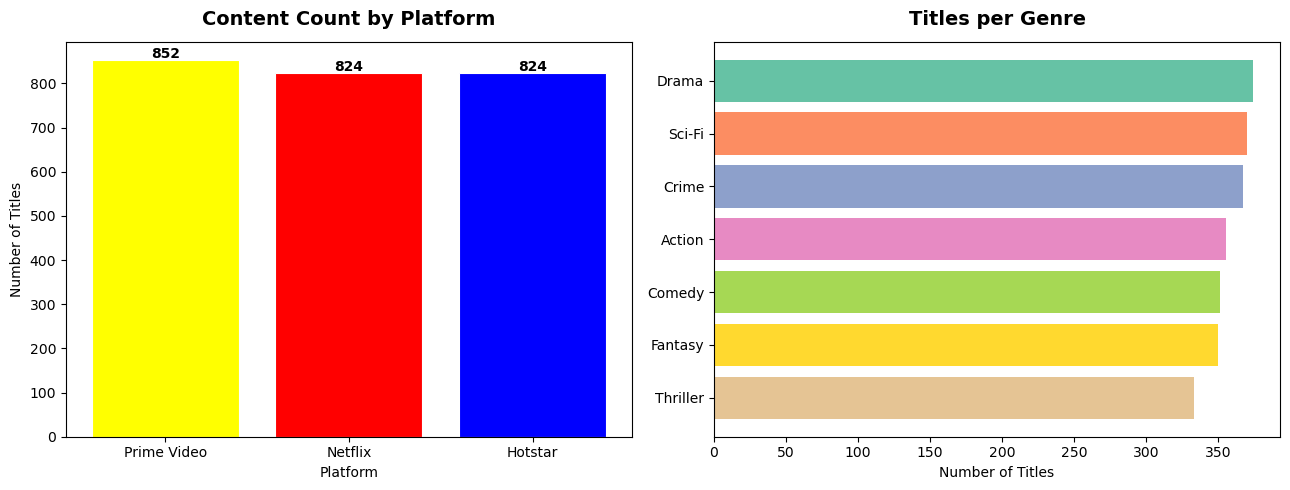

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
platform_counts = df["platform"].value_counts()
axes[0].bar(platform_counts.index, platform_counts.values,
            color=["yellow", "red", "blue"], edgecolor="white", linewidth=0.8)
axes[0].set_title("Content Count by Platform", fontsize=14, fontweight="bold", pad=12)
axes[0].set_xlabel("Platform")
axes[0].set_ylabel("Number of Titles")
for i, v in enumerate(platform_counts.values):
    axes[0].text(i, v + 5, str(v), ha="center", fontweight="bold")
genre_counts = df["genre"].value_counts()
colors = sns.color_palette("Set2", len(genre_counts))
axes[1].barh(genre_counts.index[::-1], genre_counts.values[::-1], color=colors[::-1])
axes[1].set_title("Titles per Genre", fontsize=14, fontweight="bold", pad=12)
axes[1].set_xlabel("Number of Titles")

plt.tight_layout()
plt.savefig("plot_platform_genre.png", bbox_inches="tight")
plt.show()


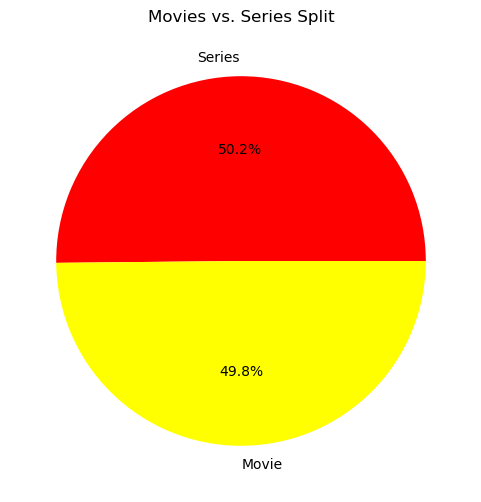

In [31]:
type_counts = df["type"].value_counts()

fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    type_counts.values,
    labels=type_counts.index,
    autopct="%1.1f%%",
    colors=["red", "yellow"]
)
ax.set_title("Movies vs. Series Split")
plt.savefig("plot_type_pie.png", bbox_inches="tight")
plt.show()

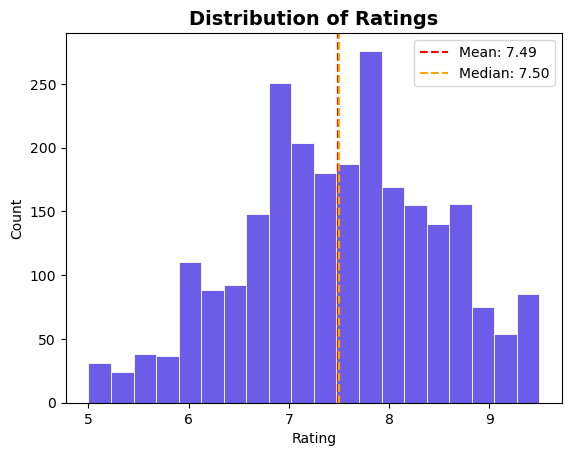

<Figure size 640x480 with 0 Axes>

In [47]:
import matplotlib.pyplot as plt

plt.hist(df["rating"], bins=20, color="#6C5CE7", edgecolor="white", linewidth=0.6)

plt.axvline(df["rating"].mean(), color="red", linestyle="--", linewidth=1.5,
            label=f'Mean: {df["rating"].mean():.2f}')

plt.axvline(df["rating"].median(), color="orange", linestyle="--", linewidth=1.5,
            label=f'Median: {df["rating"].median():.2f}')

plt.title("Distribution of Ratings", fontsize=14, fontweight="bold")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.legend()
plt.show()


plt.tight_layout()
plt.savefig("plot_ratings.png", bbox_inches="tight")
plt.show()

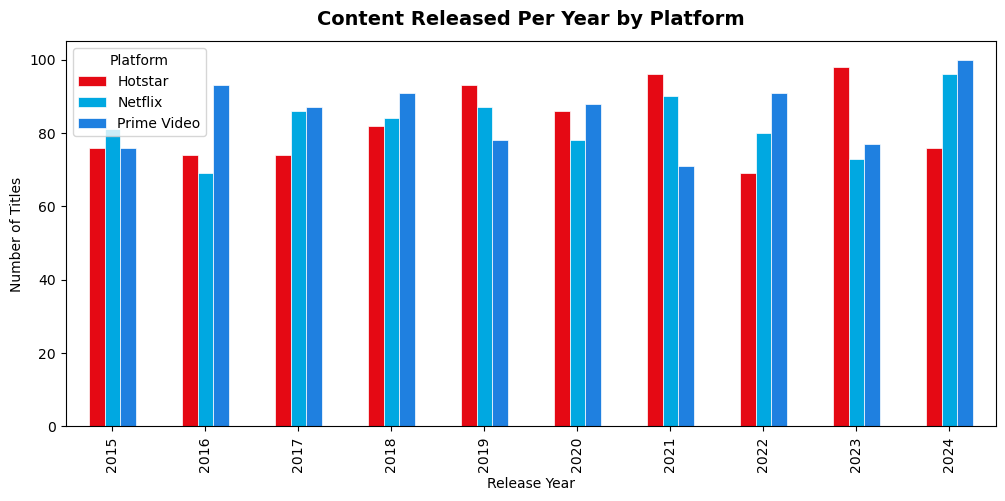

In [37]:
yearly = df.groupby(["release_year", "platform"]).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 5))
yearly.plot(kind="bar", ax=ax, color=["#E50914", "#00A8E1", "#1F80E0"],
            edgecolor="white", linewidth=0.5)
ax.set_title("Content Released Per Year by Platform", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Release Year")
ax.set_ylabel("Number of Titles")
ax.legend(title="Platform", loc="upper left")
plt.show()

C:\Users\horki\AppData\Local\Temp\ipykernel_6772\313590368.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=lang_counts.values, y=lang_counts.index, palette="viridis", ax=ax)


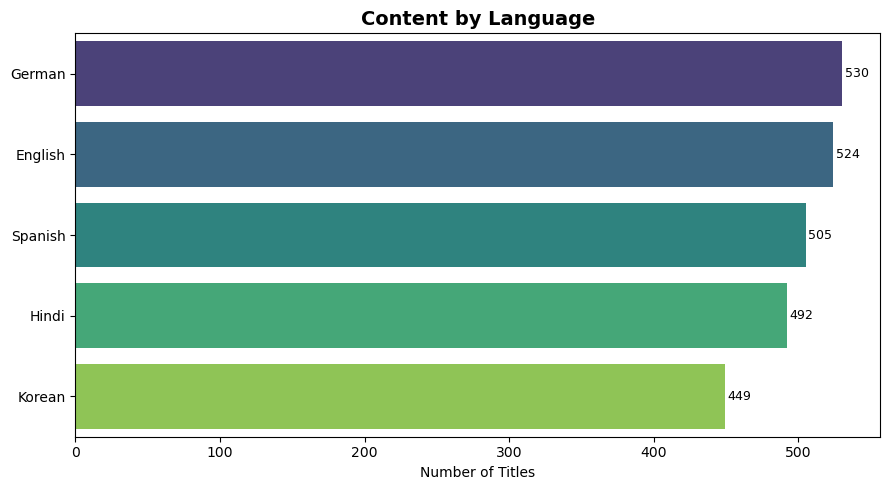

In [15]:
lang_counts = df["language"].value_counts()

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=lang_counts.values, y=lang_counts.index, palette="viridis", ax=ax)
ax.set_title("Content by Language", fontsize=14, fontweight="bold")
ax.set_xlabel("Number of Titles")
ax.set_ylabel("")
for i, v in enumerate(lang_counts.values):
    ax.text(v + 2, i, str(v), va="center", fontsize=9)
plt.tight_layout()
plt.savefig("plot_language.png", bbox_inches="tight")
plt.show()


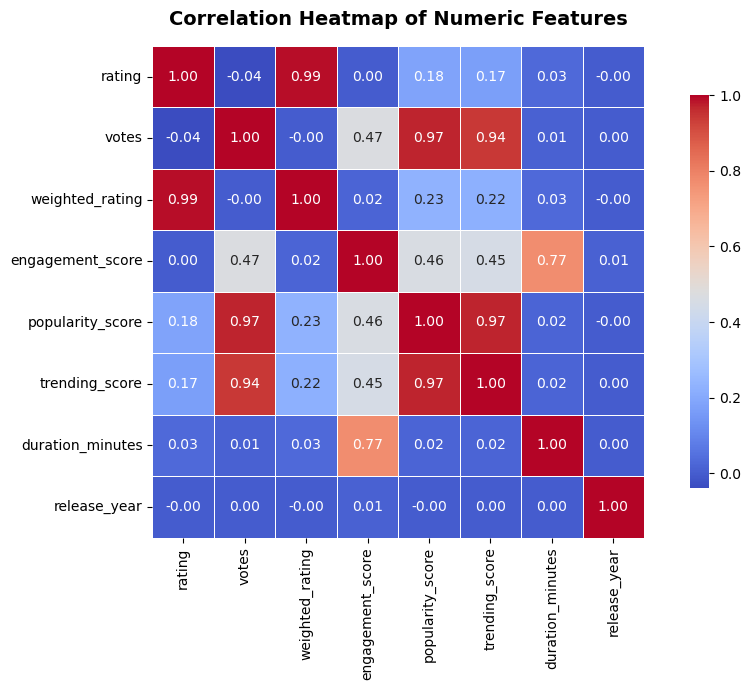

📌 Insight: Rating and weighted_rating are almost perfectly correlated (as expected).


In [16]:
numeric_cols = ["rating", "votes", "weighted_rating", "engagement_score",
                "popularity_score", "trending_score", "duration_minutes", "release_year"]

corr_matrix = df[numeric_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, square=True, ax=ax,
            cbar_kws={"shrink": 0.8})
ax.set_title("Correlation Heatmap of Numeric Features", fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig("plot_heatmap.png", bbox_inches="tight")
plt.show()
print("📌 Insight: Rating and weighted_rating are almost perfectly correlated (as expected).")


In [17]:
top10 = df.nlargest(10, "weighted_rating")[["title", "type", "genre", "platform",
                                             "release_year", "weighted_rating", "votes"]]
top10 = top10.reset_index(drop=True)
top10.index += 1          # start index from 1
top10


,title,type,genre,platform,release_year,weighted_rating,votes
1,Silent Code 146,Series,Drama,Netflix,2024,9.44,198380
2,Silent Code 2394,Series,Fantasy,Hotstar,2021,9.43,173705
3,Hidden Pulse 1060,Series,Sci-Fi,Netflix,2023,9.43,177301
4,Shadow Realm 2231,Movie,Thriller,Hotstar,2017,9.43,177423
5,Cyber Night 718,Movie,Comedy,Prime Video,2019,9.43,176562
6,Lost Signal 1314,Series,Fantasy,Prime Video,2021,9.43,187144
7,Dark Horizon 1526,Movie,Thriller,Prime Video,2019,9.43,183496
8,Neon Streets 430,Series,Crime,Netflix,2019,9.43,164069
9,Crimson Truth 2003,Movie,Sci-Fi,Prime Video,2015,9.42,142284
10,Fading Light 880,Movie,Sci-Fi,Hotstar,2016,9.42,160838


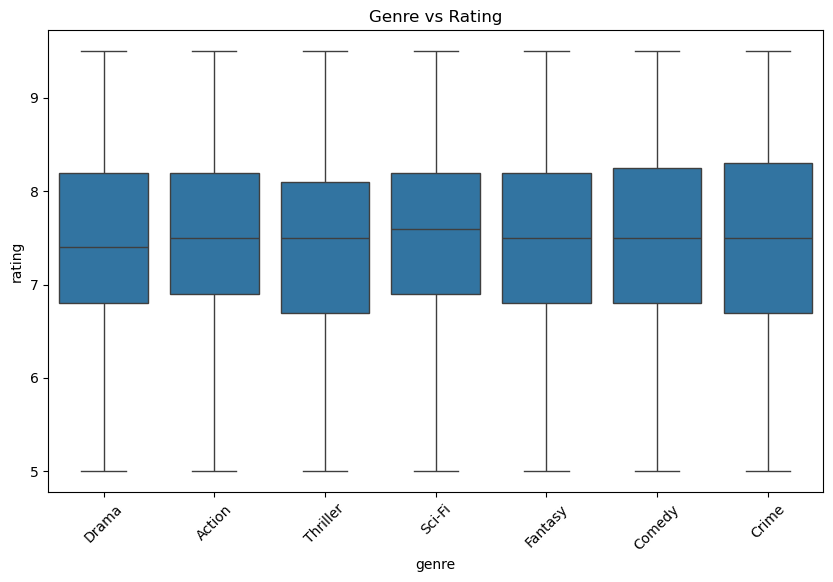

In [39]:
plt.figure(figsize=(10,6))
sns.boxplot(x='genre', y='rating', data=df)
plt.xticks(rotation=45)
plt.title('Genre vs Rating')
plt.show()


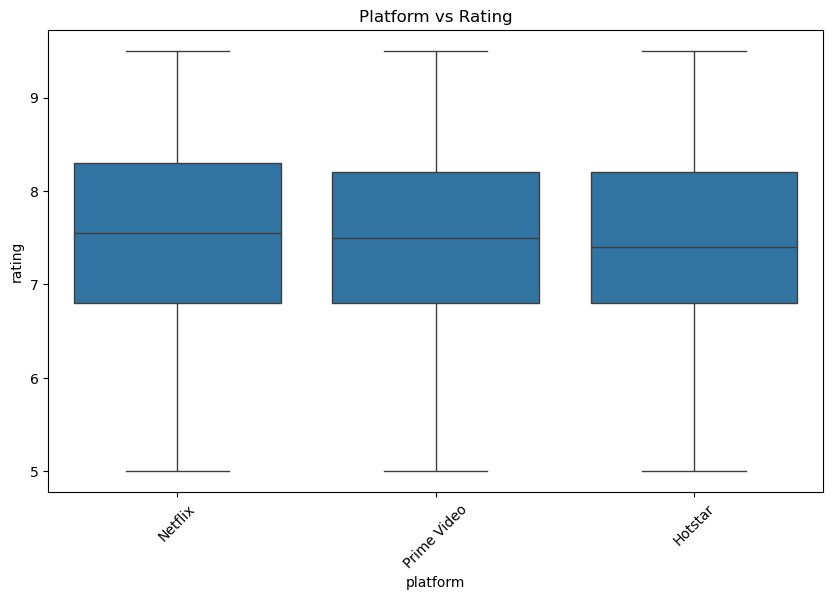

In [48]:
plt.figure(figsize=(10,6))
sns.boxplot(x='platform', y='rating', data=df)
plt.xticks(rotation=45)
plt.title('Platform vs Rating')
plt.show()


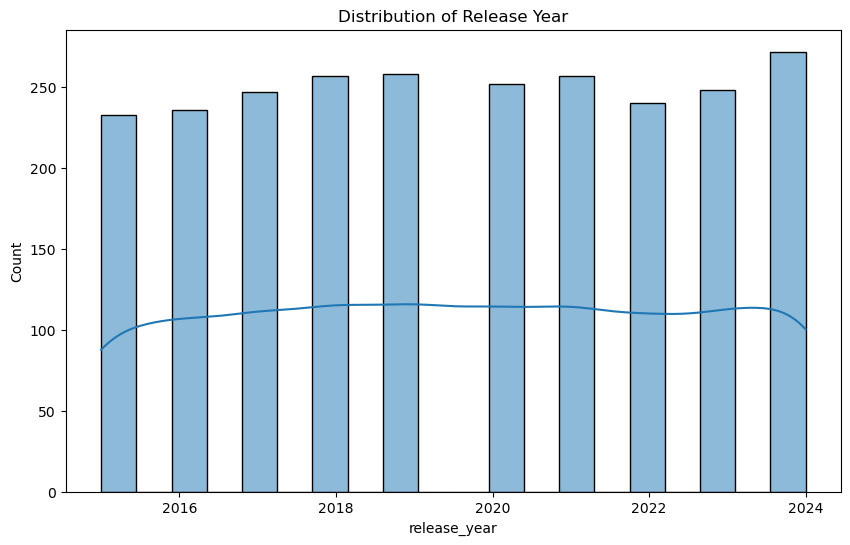

In [21]:
plt.figure(figsize=(10,6))
sns.histplot(df['release_year'], bins=20, kde=True)
plt.title('Distribution of Release Year')
plt.show()


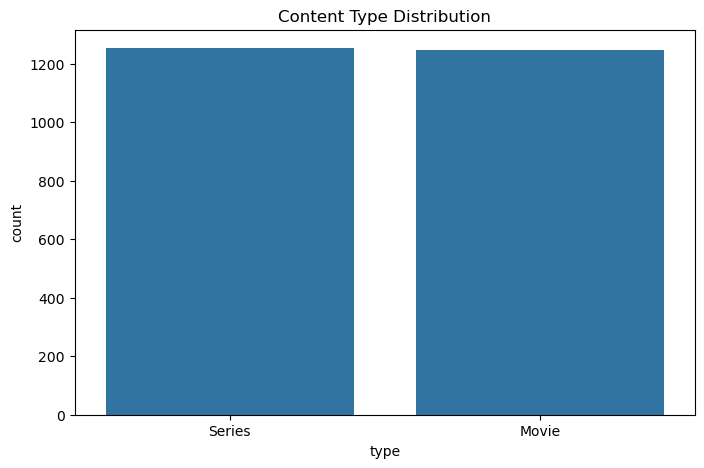

In [38]:
plt.figure(figsize=(8,5))
sns.countplot(x='type', data=df)
plt.title('Content Type Distribution')
plt.show()
